# Supplementary Figure 4

*Carvalho, Cojocaru and Fukai (2026)*

**See also:** `figure5_upload.ipynb` (results with `alpha` = 0.0693).

## 📌 User input: start here!

### 1️⃣ Exponential gap penalty

Supplementary figures use `alpha` (allowed spike-time jitter) = 0.1386 (5 ms).

### 2️⃣ Date

This notebook requires the output `run_all.py` and `movement_classes.py`. After verifying that both scripts have run, update the date of the result folder.

In [ ]:
alpha = "0.1386"
date_str = "20XX-XX-XX"

## Imports

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import collections
from scipy import stats
from statannotations.Annotator import Annotator

from import_data import import_run_all
from plot_style import *

sessions = ["071102", "071107", "071109", "071213", 
            "071214", "071218", "071221", "071227", 
            "080213", "071228", "080206", "080208", 
            "080227", "080220", "080222"]

file_name = "run_all"
path_local = "../"

path_in = path_local + "results/" + date_str + "/" + file_name + "/"

path_out = path_local + "results/" + date_str + "/paper_plots/"
if not os.path.exists(path_out):
    os.makedirs(path_out)

path_plots = path_out + f"figure5_alpha{alpha}/"
if not os.path.exists(path_plots):
    os.makedirs(path_plots)

path_out_movement = path_local + "results/movement_classes/"

(
    df_stage,
    df_comparison,
    df_neuron_concat,
    df_edge_concat,
    df_profile_concat,
    df_reward_concat_full,
    df_reward_combined_concat_full,
    df_reward_concat_prof_len,
) = import_run_all(
    sessions,
    alpha,
    path_in,
    path_out_movement,
    export=True,
)

## Helpers

In [4]:
class TestChoice:
    def __init__(self, name: str, kwargs: dict):
        self.name = name
        self.kwargs = kwargs


def cumul_dist(data):
    val_sequence = sorted(data, reverse=True)
    valCount = collections.Counter(val_sequence)
    val, cnt = zip(*valCount.items())
    cs = np.cumsum(cnt)
    return val, cs


def calc_norm(x):
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    return (x - np.median(x)) / iqr if iqr > 0 else (x - np.median(x))

## Panel B

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Profile vs. Shuffle: Mann-Whitney-Wilcoxon test two-sided, P_val:4.341e-04 U_stat=1.737e+03


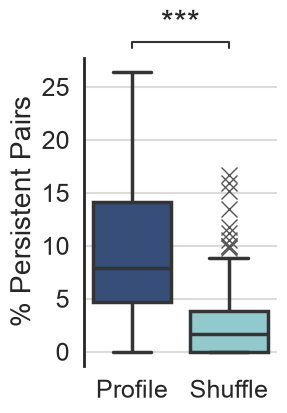

In [5]:
df = df_comparison[df_comparison["Method"].isin(["Profile", "Shuffle"])].copy()

fig, ax = plt.subplots(1, 1, figsize=(2.5, 4))
fig_args = {
    'x': 'Method',
    'y': "% Persistent Pairs",
    'data': df,
    'order': ["Profile", "Shuffle"],
    'hue': 'Method',
    'linewidth': 2.5,
    'palette': palette_methods_profshuf,
    'flierprops': {
        "marker": "x", 
        "markersize": 12, 
        "markerfacecolor": color_markers, 
        "markeredgecolor": color_markers
    }    
}
sns.boxplot(ax=ax, **fig_args)

test_choice = TestChoice('Mann-Whitney', {'alternative': 'two-sided', 'use_continuity': True})

# Specify comparison
significanceComparisons = [(("Profile"), ("Shuffle"))]

# Configure and apply test
configuration = {'test': test_choice.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False,}
annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='boxplot')
annotator.configure(**configuration).apply_test().annotate()

ax.set_xlabel("")
sns.despine(bottom=True)

for format in ["pdf"]:
    fig.savefig(path_plots + "profile_shuffle_perc_persist_pairs." + format, bbox_inches="tight", dpi=300)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Profile vs. Shuffle: Mann-Whitney-Wilcoxon test two-sided, P_val:1.429e-04 U_stat=1.636e+03


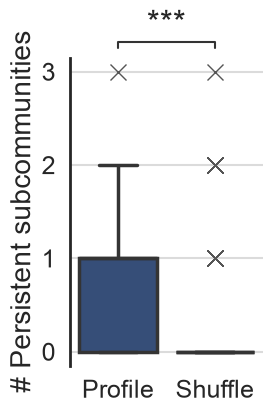

In [6]:
df = df_comparison[df_comparison["Method"].isin(["Profile", "Shuffle"])].copy()

fig, ax = plt.subplots(1, 1, figsize=(2.5, 4))
fig_args = {
    'x': 'Method',
    'y': "# Persistent Assemblies",
    'data': df,
    'order': ["Profile", "Shuffle"],
    'hue': 'Method',
    'linewidth': 2.5,
    'palette': palette_methods_profshuf,
    'flierprops': {
        "marker": "x", 
        "markersize": 12, 
        "markerfacecolor": color_markers, 
        "markeredgecolor": color_markers
    }
}
sns.boxplot(ax=ax, **fig_args)

test_choice = TestChoice('Mann-Whitney', {'alternative': 'two-sided', 'use_continuity': True})

# Specify comparison
significanceComparisons = [(("Profile"), ("Shuffle"))]

# Configure and apply test
configuration = {'test': test_choice.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False,}
annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='boxplot')
annotator.configure(**configuration).apply_test().annotate()

ax.set_ylabel("# Persistent subcommunities")
ax.set_xlabel("")
sns.despine(bottom=True)

for format in ["pdf"]:
    fig.savefig(path_plots + "profile_shuffle_num_persis_assemb." + format, bbox_inches="tight", dpi=300)

## Panel C

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Profile vs. Shuffle: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:1.996e-06 U_stat=2.131e+03
Profile vs. Corr/Lax: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:8.561e-04 U_stat=2.240e+02
Profile vs. Corr/Strict: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:2.368e-02 U_stat=2.965e+02


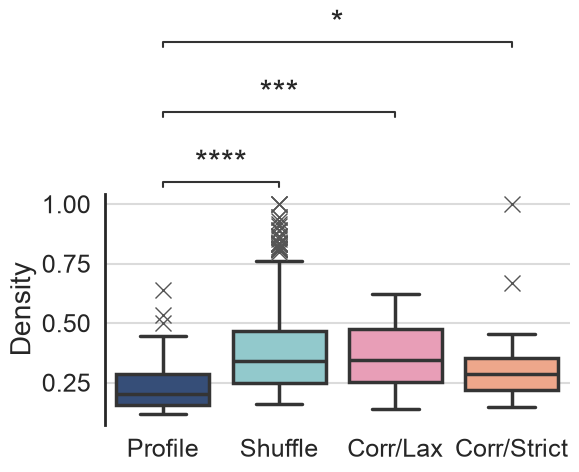

In [7]:
df = df_stage.copy()

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

local_palette = {
    "Profile": colors['blue'],
    "Shuffle": colors['cyan'],
    "Corr/Lax": colors['pink'],
    "Corr/Strict": colors['lightorange']
}

significanceComparisons = [(("Profile"), ("Shuffle")),
                           (("Profile"), ("Corr/Lax")),
                           (("Profile"), ("Corr/Strict"))]

fig_args = {
    'x': 'Method',
    'y': 'Density',
    'data': df,
    'order': ["Profile", "Shuffle", "Corr/Lax", "Corr/Strict"],
    'palette': local_palette,
    'hue': 'Method',
    'linewidth': 2.5,
    'flierprops': {
        "marker": "x", 
        "markersize": 12, 
        "markerfacecolor": color_markers, 
        "markeredgecolor": color_markers
    }
}

configuration = {'test': test_choice.name,
                    'comparisons_correction': 'HB',
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False}

sns.boxplot(ax=ax, **fig_args)

test_choice = TestChoice('Mann-Whitney', {'alternative': 'two-sided', 'use_continuity': True})
annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='barplot')
annotator.configure(**configuration).apply_test().annotate()

ax.set_xlabel("")
ax.set_ylabel("Density")

legend = ax.get_legend()
if legend is not None:
    legend.remove()

sns.despine(bottom=True)

for format in ["pdf"]:
    fig.savefig(path_plots + "density_all_methods.pdf", bbox_inches="tight", dpi=300)

## Panel D

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Profile vs. Shuffle: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:3.193e-10 U_stat=7.634e+03
Profile vs. Corr/Lax: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:1.174e-03 U_stat=6.700e+02
Profile vs. Corr/Strict: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:1.633e-05 U_stat=7.420e+02


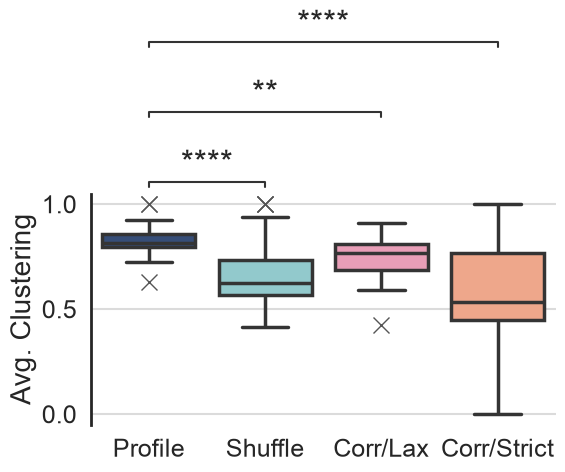

In [8]:
df = df_stage.copy()

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

local_palette = {
    "Profile": colors['blue'],
    "Shuffle": colors['cyan'],
    "Corr/Lax": colors['pink'],
    "Corr/Strict": colors['lightorange']
}

significanceComparisons = [(("Profile"), ("Shuffle")),
                           (("Profile"), ("Corr/Lax")),
                           (("Profile"), ("Corr/Strict"))]

fig_args = {
    'x': 'Method',
    'y': 'Avg Clustering',
    'data': df,
    'order': ["Profile", "Shuffle", "Corr/Lax", "Corr/Strict"],
    'palette': local_palette,
    'hue': 'Method',
    'linewidth': 2.5,
    'flierprops': {
        "marker": "x", 
        "markersize": 12, 
        "markerfacecolor": color_markers, 
        "markeredgecolor": color_markers
    }
}

configuration = {'test': test_choice.name,
                    'comparisons_correction': 'HB',
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False}

sns.boxplot(ax=ax, **fig_args)

test_choice = TestChoice('Mann-Whitney', {'alternative': 'two-sided', 'use_continuity': True})
annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='barplot')
annotator.configure(**configuration).apply_test().annotate()

ax.set_xlabel("")
ax.set_ylabel("Avg. Clustering")

legend = ax.get_legend()
if legend is not None:
    legend.remove()

sns.despine(bottom=True)

for format in ["pdf"]:
    fig.savefig(path_plots + "avg_clustering_coefficient_all_methods.pdf", bbox_inches="tight", dpi=300)

## Panel E

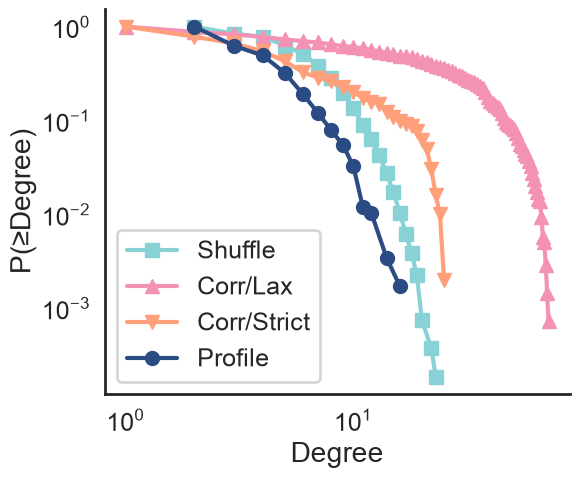

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharey=True, sharex=True)

degree_profile = df_neuron_concat[df_neuron_concat["Method"] == "Profile"]["Degree"]
degree_shuffle = df_neuron_concat[df_neuron_concat["Method"] == "Shuffle"]["Degree"]
degree_corr_lax = df_neuron_concat[df_neuron_concat["Method"] == "Corr/Lax"]["Degree"]
degree_corr_strict = df_neuron_concat[df_neuron_concat["Method"] == "Corr/Strict"]["Degree"]

degree_MR = df_neuron_concat[df_neuron_concat["Category"] == "MR"]["Degree"]
degree_UU = df_neuron_concat[df_neuron_concat["Category"] == "UU"]["Degree"]

deg, cs = cumul_dist(degree_shuffle)
ax.loglog(deg, cs/cs[-1], '-s', label="Shuffle", lw=3, color=palette_methods_4[1]) 
    
deg, cs = cumul_dist(degree_corr_lax)
ax.loglog(deg, cs/cs[-1], '-^', label="Corr/Lax", lw=3, color=palette_methods_4[2]) 

deg, cs = cumul_dist(degree_corr_strict)
ax.loglog(deg, cs/cs[-1], '-v', label="Corr/Strict", lw=3, color=palette_methods_4[3]) 

deg, cs = cumul_dist(degree_profile)
ax.loglog(deg, cs/cs[-1], '-o', label="Profile", lw=3, color=palette_methods_4[0]) 

ax.set_xticks([1,10])

ax.set_ylabel("P(≥Degree)")
ax.set_xlabel("Degree")
ax.legend()
ax.grid(False)

sns.despine()

for format in ["pdf"]:
    fig.savefig(path_plots + "degree_distribution_all_methods.pdf", bbox_inches="tight", dpi=300)

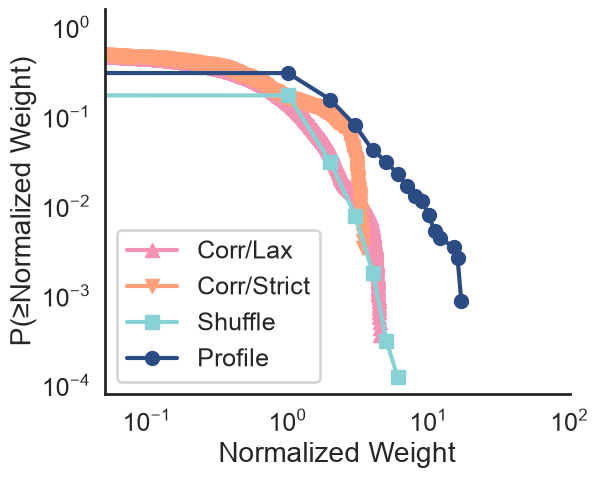

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharey=True, sharex=True)

weight_profile = df_edge_concat[df_edge_concat["Method"] == "Profile"]["Weight"]
weight_shuffle = df_edge_concat[df_edge_concat["Method"] == "Shuffle"]["Weight"]
weight_corr_lax = df_edge_concat[df_edge_concat["Method"] == "Corr/Lax"]["Weight"]
weight_corr_strict = df_edge_concat[df_edge_concat["Method"] == "Corr/Strict"]["Weight"]

norm_profile_weights = calc_norm(weight_profile)
norm_shuffle_weights = calc_norm(weight_shuffle)
norm_corr_lax_weights = calc_norm(weight_corr_lax)
norm_corr_strict_weights = calc_norm(weight_corr_strict)

deg, cs = cumul_dist(norm_corr_lax_weights)
ax.loglog(deg, cs/cs[-1], '-^', label="Corr/Lax", lw=3, color=palette_methods_4[2])

deg, cs = cumul_dist(norm_corr_strict_weights)
ax.loglog(deg, cs/cs[-1], '-v', label="Corr/Strict", lw=3, color=palette_methods_4[3])

deg, cs = cumul_dist(norm_shuffle_weights)
ax.loglog(deg, cs/cs[-1], '-s', label="Shuffle", lw=3, color=palette_methods_4[1]) 

deg, cs = cumul_dist(norm_profile_weights)
ax.loglog(deg, cs/cs[-1], '-o', label="Profile", lw=3, color=palette_methods_4[0])

ax.set_xlim(0.05, 100)

ax.set_ylabel("P(≥Normalized Weight)")
ax.set_xlabel("Normalized Weight")
ax.legend()
ax.grid(False)

sns.despine()

for format in ["pdf"]:
    fig.savefig(path_plots + "weight_distribution_profile_shuffle.pdf", bbox_inches="tight", dpi=300)